<a href="https://colab.research.google.com/github/hongdaoyang512-bit/Stock_Analysis/blob/main/Stock_Market_Prediction(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv')

In [2]:
df.head()
df['Ticker'].unique()

array(['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'TSLA'], dtype=object)

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6290 entries, 0 to 6289
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6290 non-null   object 
 1   Open       6290 non-null   float64
 2   High       6290 non-null   float64
 3   Low        6290 non-null   float64
 4   Close      6290 non-null   float64
 5   Adj Close  6290 non-null   float64
 6   Volume     6290 non-null   int64  
 7   Ticker     6290 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 393.3+ KB


,Open,High,Low,Close,Adj Close,Volume
count,6290.000000,6290.000000,6290.000000,6290.000000,6290.000000,6.290000e+03
mean,151.162151,153.244131,149.026081,151.204223,149.758827,7.490120e+07
std,80.989939,82.186810,79.665983,80.943887,80.144988,6.252449e+07
min,12.073333,12.445333,11.799333,11.931333,11.931333,8.989200e+06
25%,93.082499,94.356625,91.825003,93.113749,92.949377,3.114190e+07
50%,137.934746,139.455002,136.264999,137.790001,136.450951,5.853630e+07
75%,193.560001,196.315006,190.919998,193.577503,192.476280,9.604528e+07
max,411.470001,414.496674,405.666656,409.970001,409.970001,9.140820e+08


In [4]:
#Check if there are duplicates or null values
print(df.duplicated().sum())
df.isna().sum()

0


,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Ticker,0


In [5]:
#Return 6 largest values in 'Volume'
df_volSort = df.sort_values('Volume', ascending=False)
df_volSort.head(7)

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
5306,2020-02-04,58.863998,64.599335,55.591999,59.137333,59.137333,914082000,TSLA
5307,2020-02-05,54.883999,56.398666,46.940666,48.980000,48.980000,726357000,TSLA
5305,2020-02-03,44.912666,52.409332,44.901333,52.000000,52.000000,705975000,TSLA
5528,2020-12-18,222.966660,231.666672,209.513336,231.666672,231.666672,666378600,TSLA
5308,2020-02-06,46.661331,53.055332,45.799999,49.930668,49.930668,598212000,TSLA
5416,2020-07-13,110.599998,119.666000,98.073997,99.804001,99.804001,584781000,TSLA
5367,2020-05-01,50.333332,51.518002,45.535999,46.754665,46.754665,487977000,TSLA


In [6]:
#drop 6 largest outliers in'Volume'
df_cleaned = df[df["Volume"]<584781000]
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6284 entries, 0 to 6289
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6284 non-null   object 
 1   Open       6284 non-null   float64
 2   High       6284 non-null   float64
 3   Low        6284 non-null   float64
 4   Close      6284 non-null   float64
 5   Adj Close  6284 non-null   float64
 6   Volume     6284 non-null   int64  
 7   Ticker     6284 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 441.8+ KB


In [7]:
#Converting 'date' column to datetime and sort it
pd.to_datetime(df_cleaned['Date'])
df_cleaned = df_cleaned.sort_values("Date")

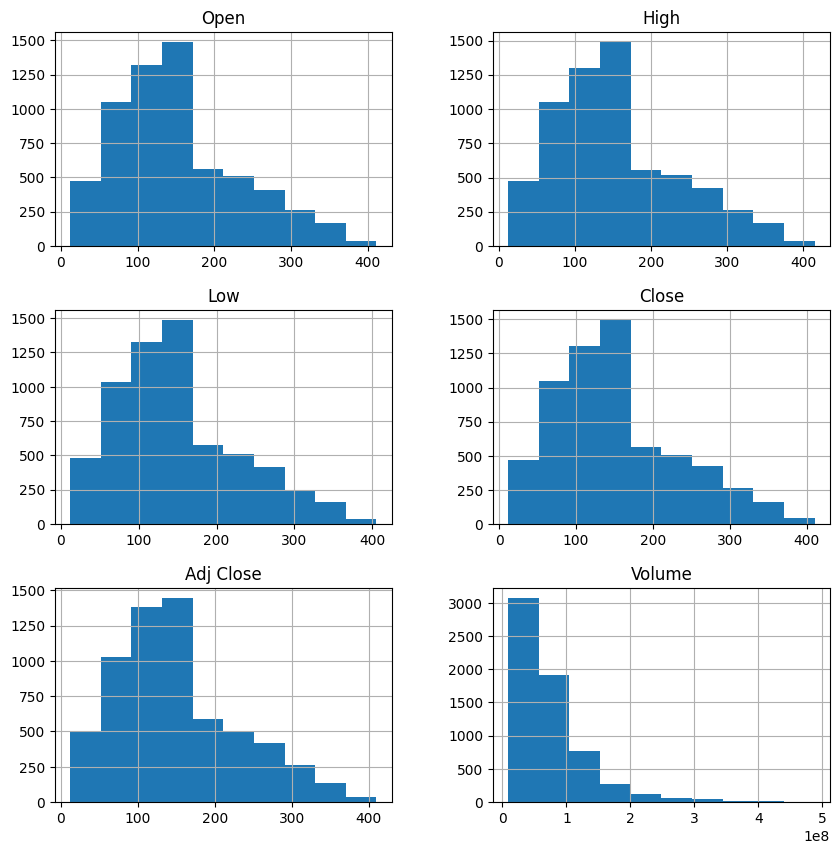

In [8]:
#Histograms
import matplotlib.pyplot as plt

prices = df_cleaned[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]
prices.hist(figsize=(10, 10))
plt.show()

               Open      High       Low     Close  Adj Close    Volume
Open       1.000000  0.999566  0.999441  0.998990   0.998668 -0.271650
High       0.999566  1.000000  0.999212  0.999470   0.999303 -0.263084
Low        0.999441  0.999212  1.000000  0.999510   0.999017 -0.281247
Close      0.998990  0.999470  0.999510  1.000000   0.999668 -0.271609
Adj Close  0.998668  0.999303  0.999017  0.999668   1.000000 -0.266598
Volume    -0.271650 -0.263084 -0.281247 -0.271609  -0.266598  1.000000


<Axes: >

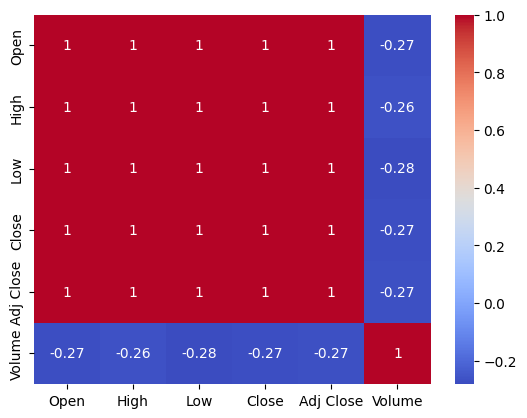

In [9]:
#Checking the correlation between variables
corrMatrix = prices.corr()
print(corrMatrix)
#Heatmap of correlation between variables
import seaborn as sns
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm')

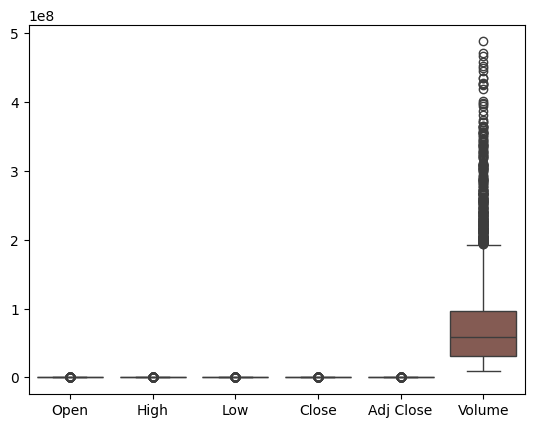

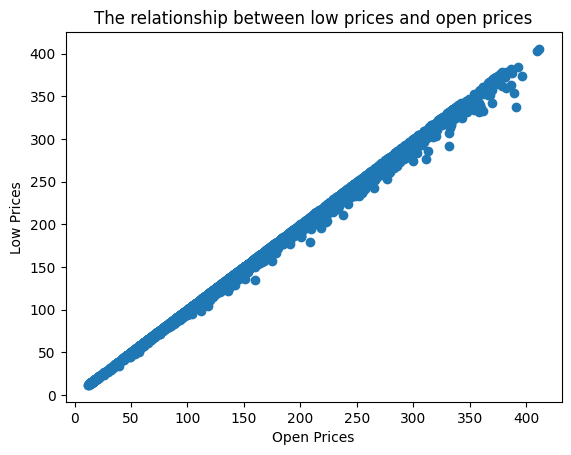

In [10]:
#Boxplots
sns.boxplot(prices)
plt.show()

#Scatter plot
plt.title('The relationship between low prices and open prices')
plt.scatter(df_cleaned['Open'], df_cleaned['Low'])
plt.xlabel('Open Prices')
plt.ylabel('Low Prices')
plt.show()

In [11]:
# Filter df_cleaned by companies
apple_data = df_cleaned[df_cleaned['Ticker'] == 'AAPL'].copy()
micro_data = df_cleaned[df_cleaned['Ticker'] == 'MSFT'].copy()
amazon_data = df_cleaned[df_cleaned['Ticker'] == 'AMZN'].copy()
google_data = df_cleaned[df_cleaned['Ticker'] == 'GOOGL'].copy()
tesla_data = df_cleaned[df_cleaned['Ticker'] == 'TSLA'].copy()


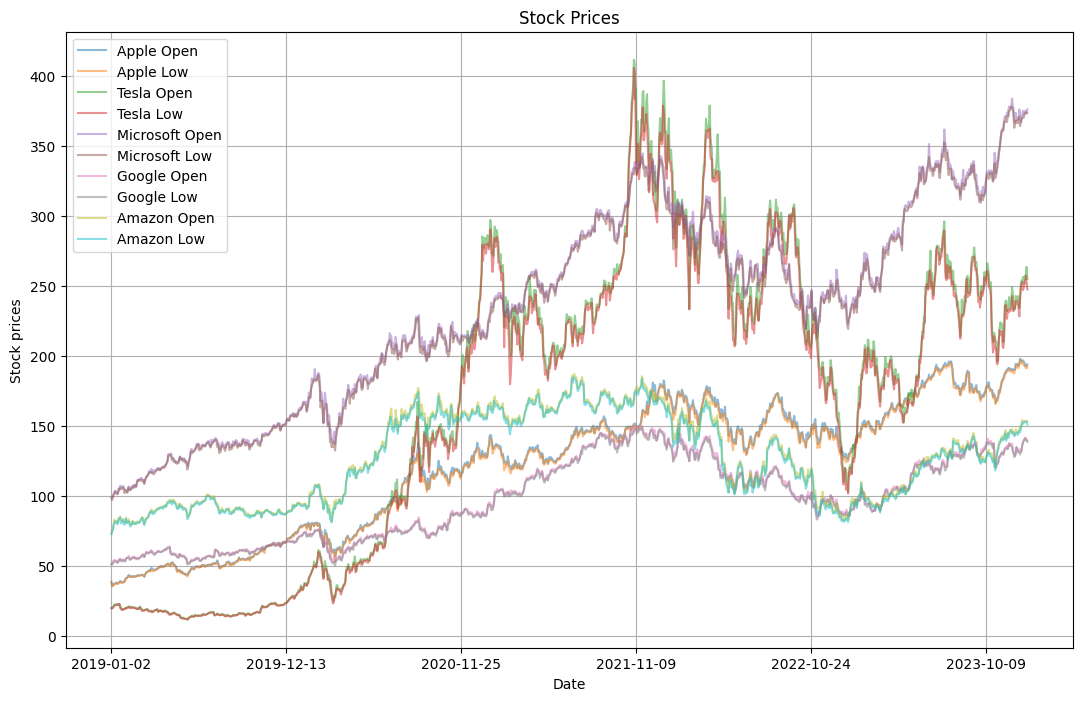

In [12]:
#line graph
plt.figure(figsize=(13, 8))
plt.xticks(np.arange(0, 1260, step=240))
plt.plot(apple_data["Date"], apple_data['Open'], label="Apple Open", alpha=0.5)
plt.plot(apple_data["Date"], apple_data["Low"], label="Apple Low", alpha=0.5)
plt.plot(tesla_data["Date"], tesla_data['Open'], label="Tesla Open", alpha=0.5)
plt.plot(tesla_data["Date"], tesla_data["Low"], label="Tesla Low", alpha=0.5)
plt.plot(micro_data["Date"], micro_data['Open'], label="Microsoft Open", alpha=0.5)
plt.plot(micro_data["Date"], micro_data["Low"], label="Microsoft Low", alpha=0.5)
plt.plot(google_data["Date"], google_data['Open'], label="Google Open", alpha=0.5)
plt.plot(google_data["Date"], google_data["Low"], label="Google Low", alpha=0.5)
plt.plot(amazon_data["Date"], amazon_data['Open'], label="Amazon Open", alpha=0.5)
plt.plot(amazon_data["Date"], amazon_data["Low"], label="Amazon Low", alpha=0.5)
plt.title("Stock Prices")
plt.xlabel("Date")
plt.ylabel("Stock prices")
plt.legend()
plt.grid(True)
plt.show()

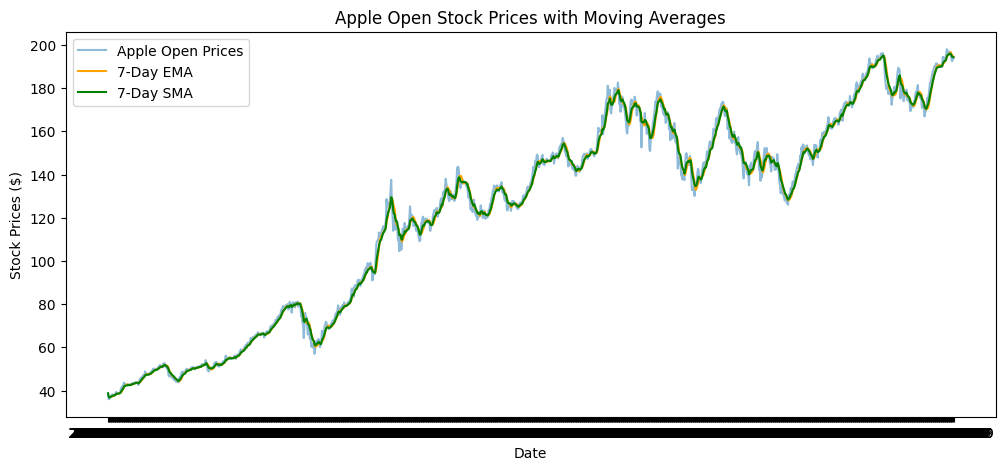

In [13]:
#EMA and SMA
apple_data['Open_EMA'] = apple_data['Open'].ewm(span=7).mean()
apple_data['Open_SMA'] = apple_data['Open'].rolling(7).mean()
plt.figure(figsize=(12, 5))
plt.plot(apple_data["Date"], apple_data['Open'], label="Apple Open Prices", alpha=0.5)
plt.plot(apple_data["Date"], apple_data['Open_SMA'], color = 'Orange', label="7-Day EMA")
plt.plot(apple_data["Date"], apple_data['Open_EMA'], color = 'Green', label="7-Day SMA")
plt.title("Apple Open Stock Prices with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Stock Prices ($)")
plt.legend()
plt.show()



In [14]:
apple_data['open_lag7'] = apple_data['Open'].shift(7)
apple_data['Rolling_mean7'] = apple_data['Open'].shift(1).rolling(7).mean()
app_features = ['Open_EMA', 'Open_SMA', 'Open', 'open_lag7', 'Rolling_mean7']

In [15]:
#training and testing data split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(apple_data[app_features],apple_data['Open'], test_size=0.2, random_state=42) # 80% train, 20% test

Mean Absolute Error (MAE): 2.0695966986028314e-14
Mean Squared Error (MSE): 7.160352699072752e-28
Root Mean Squared Error (RMSE): 2.675883536156376e-14


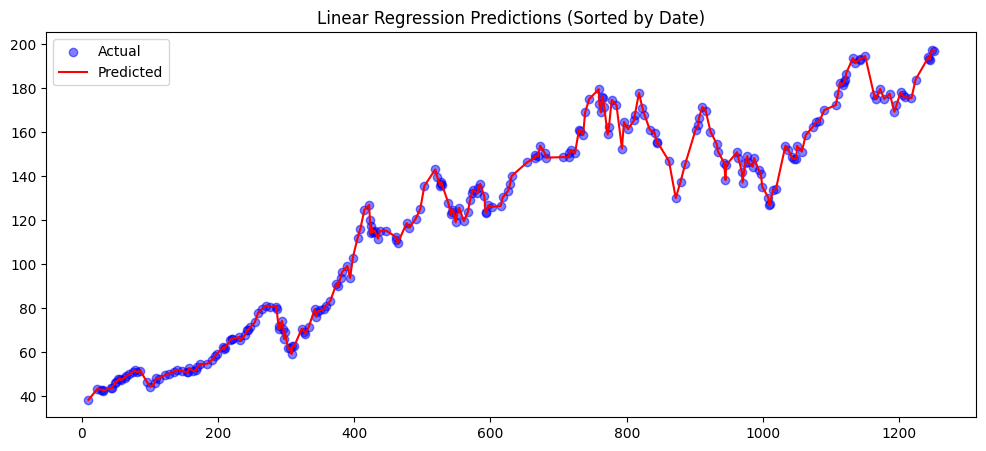

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Handle NaN values in X_train, y_train, X_test, y_test
train_df = X_train.copy()
train_df['target'] = y_train
train_df.dropna(inplace=True)

X_train_cleaned = train_df[X_train.columns]
y_train_cleaned = train_df['target']

test_df = X_test.copy()
test_df['target'] = y_test
test_df.dropna(inplace=True)

X_test_cleaned = test_df[X_test.columns]
y_test_cleaned = test_df['target']

# Convert to numpy arrays
X_train_numeric = X_train_cleaned.values
X_test_numeric = X_test_cleaned.values

LMmodel = LinearRegression()
LMmodel.fit(X_train_numeric, y_train_cleaned)

# Prediction
LMy_pred = LMmodel.predict(X_test_numeric)

# Evaluation
def mae(y_test, y_pred): return mean_absolute_error(y_test, y_pred)
def mse(y_test, y_pred): return mean_squared_error(y_test, y_pred)
def rmse(y_test, y_pred): return np.sqrt(mse(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae(y_test_cleaned, LMy_pred)}")
print(f"Mean Squared Error (MSE): {mse(y_test_cleaned, LMy_pred)}")
print(f"Root Mean Squared Error (RMSE): {rmse(y_test_cleaned, LMy_pred)}")

# Create a DataFrame for results and SORT by index (Date) to fix the plotting issue
results = pd.DataFrame({
    "Actual": y_test_cleaned,
    "Predicted": LMy_pred
}, index=y_test_cleaned.index).sort_index()

# Prediction plot
plt.figure(figsize=(12, 5))
plt.scatter(results.index, results["Actual"], label="Actual", color = 'blue', alpha=0.5)
plt.plot(results.index, results["Predicted"], label="Predicted", color='red')
plt.title("Linear Regression Predictions (Sorted by Date)")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

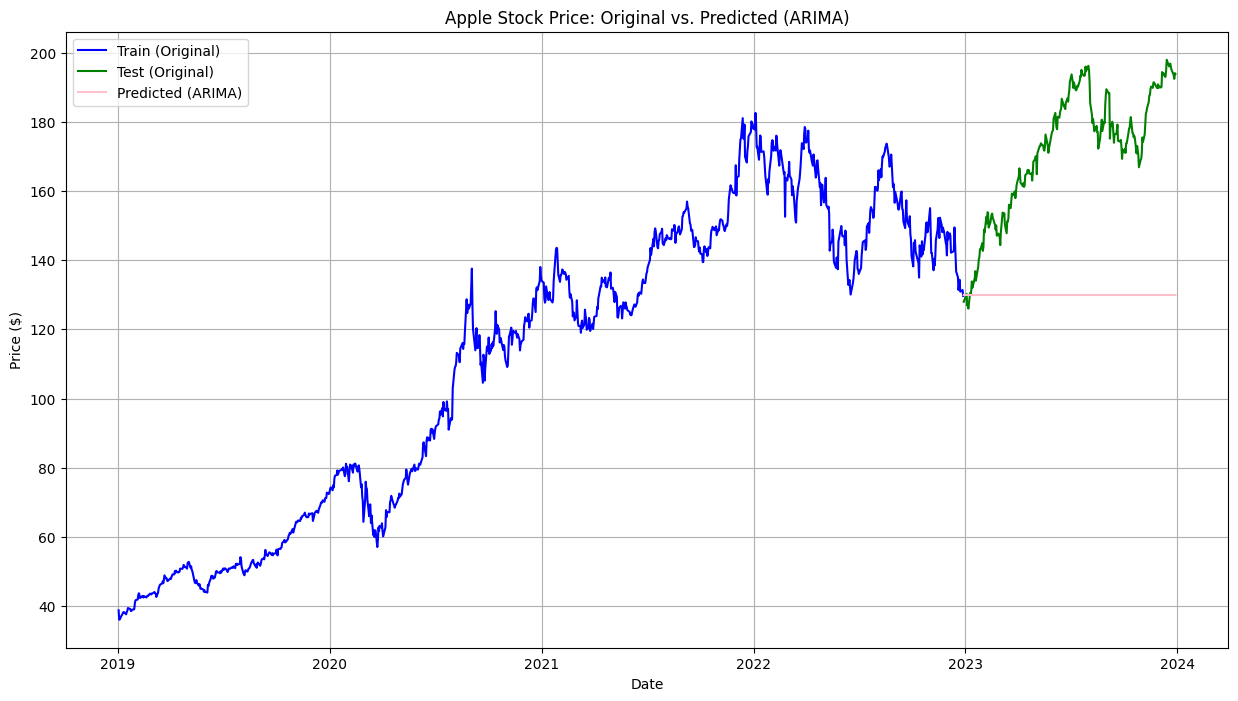

MAE for Arima prediction of Apple: 42.07
MSE for Arima prediction of Apple: 2079.84
RMSE for Arima prediction of Apple: 45.61


In [27]:
#ARIMA
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pandas as pd

# Correctly convert the 'Date' column to datetime and set as index
apple_data_arima = apple_data.copy()
apple_data_arima['Date'] = pd.to_datetime(apple_data_arima['Date'])
apple_data_arima = apple_data_arima.set_index('Date').sort_index()

# Split the data chronologically for ARIMA (80% train, 20% test)
train_size_arima = int(len(apple_data_arima) * 0.8)
train_arima = apple_data_arima['Open'].iloc[:train_size_arima]
test_arima = apple_data_arima['Open'].iloc[train_size_arima:]

# Get the dates for the test set for plotting
test_dates_arima = apple_data_arima.index[train_size_arima:]

# Initialize and fit the ARIMA model on the training data
ArimaModel = ARIMA(train_arima, order=(5,1,0))
Arima_fit = ArimaModel.fit()

# Predict on the test set
# We use the length of the sets to define the range
Arima_pred = Arima_fit.predict(start=len(train_arima), end=len(apple_data_arima)-1)
Arima_pred.index = test_dates_arima

# Plotting
plt.figure(figsize=(15,8))
plt.plot(train_arima.index, train_arima, color = 'blue', label='Train (Original)')
plt.plot(test_arima.index, test_arima, color = 'green', label='Test (Original)')
plt.plot(Arima_pred.index, Arima_pred, color = 'pink', label='Predicted (ARIMA)')
plt.title('Apple Stock Price: Original vs. Predicted (ARIMA)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

# Model evaluation
mae_arima = mae(test_arima, Arima_pred)
mse_arima = mse(test_arima, Arima_pred)
rmse_arima = rmse(test_arima, Arima_pred)
print(f"MAE for Arima prediction of Apple: {mae_arima:.2f}")
print(f"MSE for Arima prediction of Apple: {mse_arima:.2f}")
print(f"RMSE for Arima prediction of Apple: {rmse_arima:.2f}")

In [28]:
#LSTM
WINDOW_SIZE = 5

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, InputLayer, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from matplotlib.dates import MonthLocator, DateFormatter, YearLocator
import numpy as np # Import numpy for array creation

def create_lstm_sequences(data, window_size):
      X, y = [], []
      for i in range(len(data) - window_size):
          X.append(data[i:(i + window_size)])
          y.append(data[i + window_size])
      return np.array(X), np.array(y)

def train_neural_network(X, y, epochs=7, learning_rate=0.005):
      model = Sequential()
      model.add(InputLayer((WINDOW_SIZE, 1)))
      model.add(LSTM(64))
      model.add(Dense(8, 'relu'))
      model.add(Dense(1, 'linear'))

      check_point = ModelCheckpoint('model/best_model.keras', save_best_only=True, monitor='loss')
      model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate), metrics=[RootMeanSquaredError()])

      model.fit(X, y, epochs=epochs, callbacks=[check_point])
      return model

# Prepare the data for LSTM
series_data = apple_data['Open'].values # Get the numerical values
X_lstm, y_lstm = create_lstm_sequences(series_data, WINDOW_SIZE)

# Reshape X for LSTM input (samples, timesteps, features)
X_lstm = X_lstm.reshape(-1, WINDOW_SIZE, 1)

model = train_neural_network(X_lstm, y_lstm)

Epoch 1/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 15329.4512 - root_mean_squared_error: 123.8122
Epoch 2/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8599.6973 - root_mean_squared_error: 92.7346  
Epoch 3/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3297.5669 - root_mean_squared_error: 57.4244
Epoch 4/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1066.7030 - root_mean_squared_error: 32.6604
Epoch 5/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 221.5649 - root_mean_squared_error: 14.8851
Epoch 6/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 68.9634 - root_mean_squared_error: 8.3044
Epoch 7/7
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 28.5515 - root_mean_squared_error: 5.3434


In [19]:
lstm_pred = model.predict(X_test_numeric)
lstm_train = model.predict(X_train_numeric)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


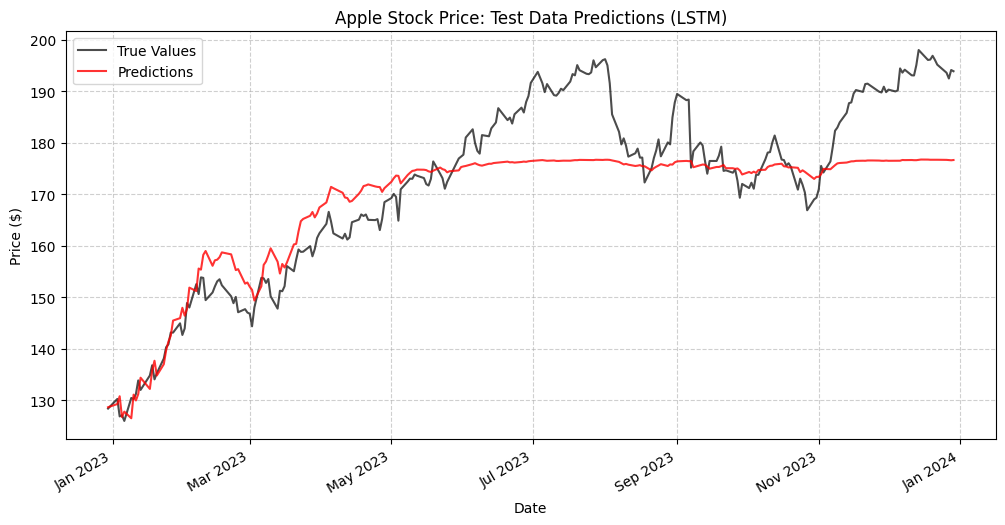

MAE for LSTM prediction: 6.80
MSE for LSTM prediction: 79.03
RMSE for LSTM prediction: 8.89


In [29]:
def plot_predictions(pred, y_true, label, period):
    # Convert period to datetime if it's not already
    period = pd.to_datetime(period)

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(period, y_true, label='True Values', color='black', alpha=0.7)
    plt.plot(period, pred, label='Predictions', color='red', alpha=0.8)
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.title(f'Apple Stock Price: {label} Predictions (LSTM)')
    plt.legend()
    plt.gca().xaxis.set_major_locator(MonthLocator(interval=2))
    plt.gca().xaxis.set_major_formatter(DateFormatter('%b %Y'))
    plt.gcf().autofmt_xdate()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# LSTM Data Preparation, Prediction, and Plotting
# Perform a chronological train-test split for the LSTM data
train_size_lstm = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:train_size_lstm], X_lstm[train_size_lstm:]
y_train_lstm, y_test_lstm = y_lstm[:train_size_lstm], y_lstm[train_size_lstm:]

# Ensure X_test_lstm is a float32 numpy array to avoid 'unknown rank' errors
X_test_lstm = np.array(X_test_lstm).astype('float32')

# Generate LSTM predictions for the test set
lstm_test_pred = model.predict(X_test_lstm)

# Get the corresponding dates for the test set
# We align the dates by skipping the first WINDOW_SIZE days
dates_for_lstm_plots = pd.to_datetime(apple_data['Date'].iloc[WINDOW_SIZE:]).values
test_dates_lstm = dates_for_lstm_plots[train_size_lstm:]

# Flatten predictions to 1D array for plotting and evaluation
predictions_flattened = lstm_test_pred.flatten()

# Plot the LSTM predictions for the test data
plot_predictions(predictions_flattened, y_test_lstm, 'Test Data', test_dates_lstm)

# Model evaluation for LSTM
# Using the globally defined mae, mse, rmse functions
mae_lstm = mae(y_test_lstm, predictions_flattened)
mse_lstm = mse(y_test_lstm, predictions_flattened)
rmse_lstm = rmse(y_test_lstm, predictions_flattened)

print(f"MAE for LSTM prediction: {mae_lstm:.2f}")
print(f"MSE for LSTM prediction: {mse_lstm:.2f}")
print(f"RMSE for LSTM prediction: {rmse_lstm:.2f}")